#Part 1
Regression Neural Network for Google Stock

In [184]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "GOOG.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shreenidhihipparagi/google-stock-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-428482009.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'google-stock-prediction' dataset.
First 5 records:   symbol                       date   close    high       low    open  \
0   GOOG  2016-06-14 00:00:00+00:00  718.27  722.47  713.1200  716.48   
1   GOOG  2016-06-15 00:00:00+00:00  718.92  722.98  717.3100  719.00   
2   GOOG  2016-06-16 00:00:00+00:00  710.36  716.65  703.2600  714.91   
3   GOOG  2016-06-17 00:00:00+00:00  691.72  708.82  688.4515  708.65   
4   GOOG  2016-06-20 00:00:00+00:00  693.71  702.48  693.4100  698.77   

    volume  adjClose  adjHigh    adjLow  adjOpen  adjVolume  divCash  \
0  1306065    718.27   722.47  713.1200   716.48    1306065      0.0   
1  1214517    718.92   722.98  717.3100   719.00    1214517      0.0   
2  1982471    710.36   716.65  703.2600   714.91    1982471      0.0   
3  3402357    691.72   708.82  688.4515   708.65    3402357      0.0   
4  2082538    693.71   702.48  693.4100   698.77    2082538      0.0   

   splitFactor  
0          1.0  

In [185]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB


In [186]:
#Clean data
import pandas as pd

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Check for missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# Check for duplicate rows
print('\nNumber of duplicate rows:')
print(df.duplicated().sum())


Missing values per column:
symbol         0
date           0
close          0
high           0
low            0
open           0
volume         0
adjClose       0
adjHigh        0
adjLow         0
adjOpen        0
adjVolume      0
divCash        0
splitFactor    0
dtype: int64

Number of duplicate rows:
0


In [187]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):

        #Initialize weights for input to hidden layer
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * np.sqrt(1. / input_size)

        #Initialize biases for hidden layer
        self.bias_input_hidden = np.zeros((1, hidden_size))

        #Initialize weights for hidden to output layer
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * np.sqrt(1. / hidden_size)

        #Initialize biases for output layer
        self.bias_hidden_output = np.zeros((1, output_size))

    def forward(self, X):
        #Calculate the weighted sum of inputs for the hidden layer
        self.z_hidden = np.dot(X, self.weights_input_hidden) + self.bias_input_hidden

        #Apply the Rectified Linear Unit (ReLU) activation function
        self.a_hidden = np.maximum(0, self.z_hidden)

        #Calculate the weighted sum for the output layer
        self.z_output = np.dot(self.a_hidden, self.weights_hidden_output) + self.bias_hidden_output

        #The final prediction y_pred will be self.z_output (linear activation for regression)
        y_pred = self.z_output

        #Return y_pred
        return y_pred

    def compute_cost(self, y_pred, y_true):
        #Calculate the difference between predictions and true values
        errors = y_pred - y_true

        #Square this difference
        squared_errors = np.square(errors)

        #Calculate the mean of the squared differences (MSE)
        mse = np.mean(squared_errors)

        return mse

    def backward(self, X, y_true, y_pred):
        m = y_true.shape[0] # Number of samples

        #Calculate the error for the output layer
        d_output_error = 2 * (y_pred - y_true) / m

        #Calculate gradients for hidden to output layer weights and biases
        self.d_weights_hidden_output = np.dot(self.a_hidden.T, d_output_error)
        self.d_bias_hidden_output = np.sum(d_output_error, axis=0, keepdims=True)

        #Propagate the error back to the hidden layer
        #Derivative of the hidden layer activation (ReLU) with respect to its input (z_hidden)
        d_hidden_activation = d_output_error.dot(self.weights_hidden_output.T) * (self.z_hidden > 0)

        #Calculate gradients for input to hidden layer weights and biases
        self.d_weights_input_hidden = np.dot(X.T, d_hidden_activation)
        self.d_bias_input_hidden = np.sum(d_hidden_activation, axis=0, keepdims=True)

    def train(self, X_train, y_train, epochs, learning_rate):
        for epoch in range(epochs):
            #Perform a forward pass
            y_pred = self.forward(X_train)

            #Calculate the cost
            cost = self.compute_cost(y_pred, y_train)

            #Perform a backward pass
            self.backward(X_train, y_train, y_pred)

            #Update the weights and biases
            self.weights_input_hidden -= learning_rate * self.d_weights_input_hidden
            self.bias_input_hidden -= learning_rate * self.d_bias_input_hidden
            self.weights_hidden_output -= learning_rate * self.d_weights_hidden_output
            self.bias_hidden_output -= learning_rate * self.d_bias_hidden_output



    def predict(self, X_test):
        #Calculate the weighted sum of inputs for the hidden layer
        z_hidden_test = np.dot(X_test, self.weights_input_hidden) + self.bias_input_hidden

        #Apply the Rectified Linear Unit (ReLU) activation function
        a_hidden_test = np.maximum(0, z_hidden_test)

        #Calculate the weighted sum for the output layer
        y_pred_test = np.dot(a_hidden_test, self.weights_hidden_output) + self.bias_hidden_output

        #Return the final output layer activation as the prediction
        return y_pred_test

In [188]:
from sklearn.preprocessing import MinMaxScaler #rescales numerical features to a fixed range, usually between 0 and 1.

# Select features (X) and target (y)
#Use 'open', 'high', 'low', 'close', 'volume' as features to predict the 'close' price.
features = ['open', 'high', 'low', 'close', 'volume']
X = df[features].values

# The target will be the 'close' price shifted by one day for prediction
y = df['close'].shift(-1).values

# Drop the last row
X = X[:-1]
y = y[:-1]

#Scale the features and target
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

print("Shape of X_scaled:", X_scaled.shape)
print("Shape of y_scaled:", y_scaled.shape)

Shape of X_scaled: (1257, 5)
Shape of y_scaled: (1257, 1)


In [189]:
# Define the network parameters
# Number of features
input_size = X_train.shape[1]
hidden_size = 50
# Number of output values (1 for close price)
output_size = y_train.shape[1]

# Create an instance of the NeuralNetwork
model = NeuralNetwork(input_size, hidden_size, output_size)

print(f"Neural Network model created with input_size={input_size}, hidden_size={hidden_size}, output_size={output_size}")

Neural Network model created with input_size=5, hidden_size=50, output_size=1


In [190]:
# Define the split ratio (e.g., 80% for training, 20% for testing)
train_size = int(len(X_scaled) * 0.8)

X_train, X_test = X_scaled[0:train_size,:], X_scaled[train_size:len(X_scaled),:]
y_train, y_test = y_scaled[0:train_size,:], y_scaled[train_size:len(y_scaled),:]

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1005, 5)
Shape of y_train: (1005, 1)
Shape of X_test: (252, 5)
Shape of y_test: (252, 1)


In [191]:
# Define training parameters
epochs = 1000 # Number of training iterations
learning_rate = 0.01 # Step size for weight updates

print(f"Starting training for {epochs} epochs with a learning rate of {learning_rate}")

# Train the model
model.train(X_train, y_train, epochs, learning_rate)

print("Training complete!")

Starting training for 1000 epochs with a learning rate of 0.01
Training complete!


In [192]:
# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

print("Predictions on test set generated.")

Predictions on test set generated.


In [193]:
from sklearn.metrics import mean_squared_error

# Inverse transform the scaled predictions and actual values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Root Mean Squared Error (RMSE): 46.0787


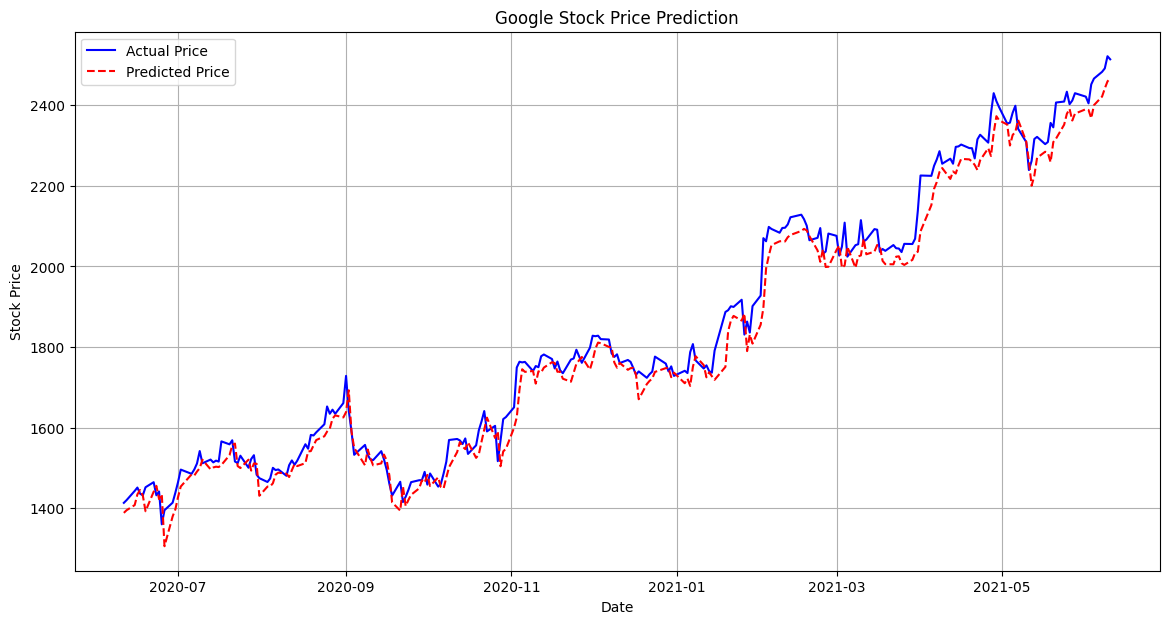

In [194]:
import matplotlib.pyplot as plt

# Get the dates corresponding to the test set
# Since X and y were sliced by [:-1], we need to apply that to the dates as well
df_dates = df['date'][:-1]

# Get the test dates using the same train_size split
test_dates = df_dates[train_size:]

# Create a plot
plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual Price', color='blue')
plt.plot(test_dates, y_pred, label='Predicted Price', color='red', linestyle='--')
plt.title('Google Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

For Part 1 I didnt need to use any  minibatch which or any technique since my data ran pretty fast

#Part 2

##Task 1
These resources helped me understand the strucutre of a  2 layer NN LSTM and how it will work in TensorFlow before starting

Resources: https://www.geeksforgeeks.org/nlp/stock-price-prediction-project-using-tensorflow/
https://blog.mlreview.com/a-simple-deep-learning-model-for-stock-price-prediction-using-tensorflow-30505541d877
https://thepythoncode.com/article/stock-price-prediction-in-python-using-tensorflow-2-and-keras

##Task 2

###EDA

In [203]:
#Clean data
import pandas as pd

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Check for missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# Check for duplicate rows
print('\nNumber of duplicate rows:')
print(df.duplicated().sum())


Missing values per column:
symbol         0
date           0
close          0
high           0
low            0
open           0
volume         0
adjClose       0
adjHigh        0
adjLow         0
adjOpen        0
adjVolume      0
divCash        0
splitFactor    0
dtype: int64

Number of duplicate rows:
0


Time series data preprocessing

In [195]:
import numpy as np

#Define a look_back window
#Number of previous days' data to use for predicting the next day's stock price
look_back = 100

#Create empty lists for input sequences and target values
X_lstm = []
y_lstm = []

#Iterate through the data to create sequences
# Start from look_back index
for i in range(look_back, len(X_scaled)):

  #Extract sequence of 'look_back' length
    X_lstm.append(X_scaled[i-look_back:i])

    #The target is the y_scaled value at the current index
    y_lstm.append(y_scaled[i])

#Convert lists to NumPy arrays
X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

#X_lstm to 3D array: (number_of_samples, look_back, number_of_features)
#The number of features is already handled by X_scaled[i-look_back:i]
print("Shape of X_lstm:", X_lstm.shape)
print("Shape of y_lstm:", y_lstm.shape)

Shape of X_lstm: (1157, 100, 5)
Shape of y_lstm: (1157, 1)


###Train-dev-test split

In [196]:
import numpy as np

#Define the proportions for the training, validation, and test sets
#Sums to 1
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

#Calculate the number of samples for each set
total_samples = len(X_lstm)

train_size = int(total_samples * train_ratio)
val_size = int(total_samples * val_ratio)

#The test size takes the rest to ensure all samples are used
test_size = total_samples - train_size - val_size

#Split X_lstm and y_lstm into training, validation, and test sets chronologically
X_train_lstm, y_train_lstm = X_lstm[0:train_size], y_lstm[0:train_size]
X_val_lstm, y_val_lstm = X_lstm[train_size:train_size + val_size], y_lstm[train_size:train_size + val_size]
X_test_lstm, y_test_lstm = X_lstm[train_size + val_size:], y_lstm[train_size + val_size:]

#Print the shapes of the training, validation, and test sets
print(f"Shape of X_train_lstm: {X_train_lstm.shape}")
print(f"Shape of y_train_lstm: {y_train_lstm.shape}")
print(f"Shape of X_val_lstm: {X_val_lstm.shape}")
print(f"Shape of y_val_lstm: {y_val_lstm.shape}")
print(f"Shape of X_test_lstm: {X_test_lstm.shape}")
print(f"Shape of y_test_lstm: {y_test_lstm.shape}")

Shape of X_train_lstm: (809, 100, 5)
Shape of y_train_lstm: (809, 1)
Shape of X_val_lstm: (173, 100, 5)
Shape of y_val_lstm: (173, 1)
Shape of X_test_lstm: (175, 100, 5)
Shape of y_test_lstm: (175, 1)


###3. Forward Propagation
Activation function I had used were the Dense Output Layer as welll as LSTM include internal activation functions like sigmoid and tanh

Hyperparameters consisted of look_back window of 100 and units =50 for the lstm layers

In [197]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

#Initialize a Sequential model
model_lstm = Sequential()

# Add the first LSTM layer
# input_shape should be (timesteps, features)
# X_train_lstm.shape[1] is look_back, X_train_lstm.shape[2] is number_of_features
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

# Add a second LSTM layer
model_lstm.add(LSTM(units=50, return_sequences=False))

# Add a Dense output layer
model_lstm.add(Dense(units=1))

# Print the model summary
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 50)        │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

### Gradient descent, For this problem I had used the adam optimizer, the model performs much better when inputs are normalized otherwise I had noticed it makes inaccurate predictions when it is not normalized and skews our root mean squared error. We didnt want overly large data to cause conflicts with other parts of our data and that would have been a big problem. Without normalizing the data features with larger numerical ranges could influence the learning process of our model negatively

In [198]:
import tensorflow as tf

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

print("LSTM model compiled with Adam optimizer and Mean Squared Error loss.")

LSTM model compiled with Adam optimizer and Mean Squared Error loss.


In [199]:
epochs_lstm = 100
batch_size_lstm = 32

print(f"Starting LSTM model training for {epochs_lstm} epochs with batch size {batch_size_lstm}.")

history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=epochs_lstm,
    batch_size=batch_size_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    verbose=1
)

print("LSTM model training complete!")

Starting LSTM model training for 100 epochs with batch size 32.
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0174 - val_loss: 0.0023
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.1496e-04 - val_loss: 0.0021
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.8652e-04 - val_loss: 0.0022
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.2276e-04 - val_loss: 0.0020
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.2074e-04 - val_loss: 0.0022
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.3092e-04 - val_loss: 0.0019
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9578e-04 - val_loss: 0.0018
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9189e-04 - val_loss: 0.0017
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.8086e-04 - val_loss: 0.0017
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.1057e-04 - val_loss: 0.0016
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━

In [200]:
y_pred_lstm_scaled = model_lstm.predict(X_test_lstm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predictions on LSTM test set generated.


In [201]:
from sklearn.metrics import mean_squared_error

# Inverse transform the scaled predictions to original prices
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
y_test_lstm_actual = scaler_y.inverse_transform(y_test_lstm)

# Calculate Root Mean Squared Error (RMSE)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_actual, y_pred_lstm))

print(f"LSTM Model Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")

LSTM Model Root Mean Squared Error (RMSE): 72.0483


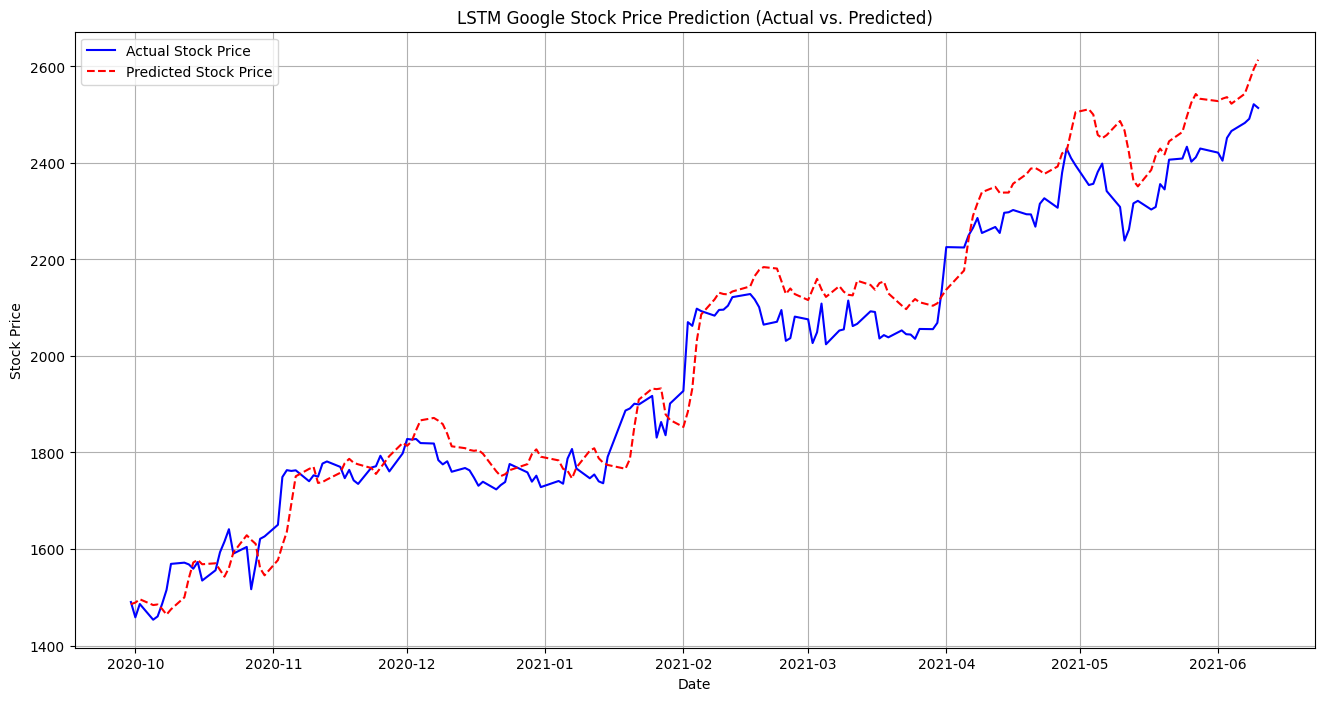

In [202]:
import matplotlib.pyplot as plt

full_dates_for_lstm = df_dates[look_back:].reset_index(drop=True)
test_dates_lstm = full_dates_for_lstm[train_size + val_size:].reset_index(drop=True)

plt.figure(figsize=(16, 8))
plt.plot(test_dates_lstm, y_test_lstm_actual, label='Actual Stock Price', color='blue')
plt.plot(test_dates_lstm, y_pred_lstm, label='Predicted Stock Price', color='red', linestyle='--')
plt.title('LSTM Google Stock Price Prediction (Actual vs. Predicted)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

##Task 3
For the hyperparamater selection I had used a look_back window of 1000 days and 50 units for each LSTM layer which are starting pints for a time series forecasting model. The rationale behind using an LSTM is that stock prices are time-dependent sequences where the current price is heavily influenced by historical patterns. Standard neural networks lack the feedback loops necessary to store this history, whereas the LSTM's gating mechanism allows it to selectively retain long-term dependencies and discard short-term noise, leading to a more stable and accurate prediction of future price movements.
I did not use regularizaton because applying L2 Regularization  smoothed out the data becase due to L2 regulariztion weight decay it would prioritize smaller weights which makes an LSTM less sensitive to sudden changes, instead of reacting to each sharp movement, which results in a smoother line.
For my optimization algorithim I had used ADAM since it will reach the optimal weights I need much faster and doesnt require as much manual tuning of the initial learning rate. Adam alsos helps with noisy data such as our stock prediction since it combines both RMSProp and Momentum